# Lick Analysis For All Mice - Operand Conditioning

In [2]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import joypy

In [3]:
# paste the random sequence defining what trials are go/no go from the operand code
# 0 = reward, 1 = no reward
random_seq = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
                0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
                0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
                0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
                1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
                0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

# Main Function
Uses the defined path to load the .pkl files, extract and normalize the lick times, and organize it into a dataframe

In [4]:
#load data
path = r"D:\mz_Data\RECORDING_DATA\lick_data\oper_rec_licks\CC067489_HP2_RecInter_2021-08-06_10-25-48.pkl"

f=open(path, 'rb')
objs = []
while 1:
    try:
        objs.append(pickle.load(f))
    except EOFError:
        break
f.close()

In [5]:
# u = start of trial
# r = timestamp of reward
# o = stimulus with no reward

#load data and extract lick times
stim_dur = 1
rew_time_ls = []
no_rew_time_ls = []
nolickls= []
for idx, x in enumerate(objs):
    if random_seq[idx] == 0:
        try:
            rew_time_ls.append(x.split("r")[1].split(" ")[0].split("u")[0])
        except:
            nolickls.append(x.split("m")[1].split(" ")[0].split("u")[0])
            #print("Error{0}".format(idx))
    elif random_seq[idx] == 1:
        try:
            no_rew_time_ls.append(x.split("o")[1].split(" ")[0].split("u")[0])
        except:
            print("Error{0}".format(idx))
print(len(nolickls))
print(len(rew_time_ls))
print(len(no_rew_time_ls))

IndexError: list index out of range

In [39]:
#converting the string to an array
rew_time_ar = np.array(rew_time_ls, dtype=np.float32)
rew_time_ar = rew_time_ar
no_rew_time_ar = np.array(no_rew_time_ls, dtype=np.float32)
no_rew_time_ar = no_rew_time_ar
nolickls_ar = np.array(nolickls, dtype=np.float32)

#subtracting the stimulus duration
stim_timeswithlicks = rew_time_ar - stim_dur
stim_timeswithlicks #start times of each rewarded stimulus - this is our 0 time point
stim_timesnolicks = nolickls_ar - stim_dur
stim_timesnolicks #start times of each rewarded stimulus without licks - this is our 0 time point
no_stim_times = no_rew_time_ar - stim_dur
no_stim_times #start times of each stimulus with no reward - this is our 0 time point

#removing the 'u','r' and 'o' identifiers
cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]
rew_cleaned_objslicks = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]

rew_cleaned_objsnolicks = [ x.replace('m',' ') for x in cleaned_objs if 'm' in x]
norew_cleaned_objs = [ x.replace('o',' ') for x in cleaned_objs if 'o' in x ]

57
43
50


# Create the Data Frame

In [40]:
rew_lick_timeslicks = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned_objslicks ]
rew_lick_timesnolicks = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned_objsnolicks ]
norew_lick_times = [np.array(x.strip().split(" "), dtype=np.float32) for x in norew_cleaned_objs ]

for idx, val in enumerate(rew_time_ar):
    rew_lick_timeslicks[idx] =  rew_lick_timeslicks[idx][rew_lick_timeslicks[idx] != val]
for idx, val in enumerate(nolickls_ar):
    rew_lick_timesnolicks[idx] = rew_lick_timesnolicks[idx][rew_lick_timesnolicks[idx] != val]
for idx, val in enumerate(no_rew_time_ar):
    norew_lick_times[idx] =  norew_lick_times[idx][norew_lick_times[idx] != val]

# Create data frame for the rewarded trials
rew_df = pd.DataFrame(rew_lick_timeslicks).sub(stim_timeswithlicks, axis = 0)
num_rew_tr = rew_df.shape[0]

# Create a data frame for the rewarded trials that had no licks during stim time
rew_nolick_df = pd.DataFrame(rew_lick_timesnolicks).sub(stim_timesnolicks, axis = 0)
num_rewnolick_tr = rew_nolick_df.shape[0]

# Create data frame for the unrewarded trials
norew_df = pd.DataFrame(norew_lick_times).sub(no_stim_times, axis = 0)
num_norew_tr = norew_df.shape[0]

    
# Concatenate the individual data frames (rewarded stacked on top of not rewarded)
# use ignore_index so that the index goes 1-146 instead of 1-97 and then 1-49
df_licks = pd.concat([rew_df, rew_nolick_df, norew_df], ignore_index=True)

# Remove the first stimulus because of the massive delay present in the recording
# its the delay used to position the delivery so that the mouse doesn't get the massive flow
df_licks.drop(df_licks.index[0], inplace=True)

df_licks2 = pd.DataFrame(df_licks.stack())

# Create a new column with stimulus id (rewarded vs unrewarded/none)
# loop through df_licks2 trials and check if still in range(num_rew_tr) or range(rew_df)

In [41]:
test = df_licks.to_numpy()
test

array([[-2.31000137, -1.31999969, -1.25999832, ...,         nan,
                nan,         nan],
       [-2.37000275, -2.30000305, -2.25      , ...,         nan,
                nan,         nan],
       [-2.1000061 , -2.04000092, -1.89000702, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])

In [42]:
list_of_licks_per_trial = []
counter = 0
for i in range(num_norew_tr+num_rewnolick_tr+num_rew_tr-1):
    for value in test[i]:
        if value > -100000000 and value < 10000000:
            counter += 1
        else:
            break
    list_of_licks_per_trial.append(counter)
    counter = 0 
print(len(list_of_licks_per_trial))
print(list_of_licks_per_trial)

149
[64, 70, 71, 46, 48, 58, 55, 45, 53, 74, 50, 46, 79, 50, 57, 56, 67, 38, 27, 58, 60, 51, 69, 44, 66, 50, 59, 59, 57, 36, 45, 56, 59, 51, 38, 51, 54, 59, 62, 38, 25, 39, 25, 28, 13, 20, 0, 0, 0, 0, 23, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 25, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 50, 35, 30, 32, 57, 44, 36, 35, 39, 46, 48, 41, 21, 28, 34, 45, 25, 38, 23, 28, 25, 35, 40, 23, 35, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [43]:
list_reward_and_none = []
for i, value in enumerate(list_of_licks_per_trial):
    for j in range(value):
        if i < num_rew_tr:       # Check if it's less than or less than or equal
            list_reward_and_none.append("reward")
        elif i > num_rew_tr and i <(num_rew_tr+num_rewnolick_tr):
            list_reward_and_none.append("reward")
        else:
            list_reward_and_none.append("unrew")

['reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward', 'reward',

## Reset Index of Dataframe

In [44]:
df_licks2 = df_licks2.reset_index()
df_licks2.columns = ["trial", "lick_idx", "lick_time"]

df_licks2["stim id"] = list_reward_and_none
df_licks2

,trial,lick_idx,lick_time,stim id
0,1,0,-2.310001,reward
1,1,1,-1.320000,reward
2,1,2,-1.259998,reward
3,1,3,-1.049999,reward
4,1,4,0.339996,reward
...,...,...,...,...
3272,124,30,10.559998,none
3273,124,31,10.630005,none
3274,124,32,10.830017,none
3275,124,33,12.160034,none


In [45]:
stim_lb = 0.0 #lower bound of stimulus time
stim_ub = 0.2 #upper bound of stimulus time
rew_lb = stim_ub+1.0
rew_ub = stim_ub+1.0+0.2
stim_dur = 0.2

# Raster Plot

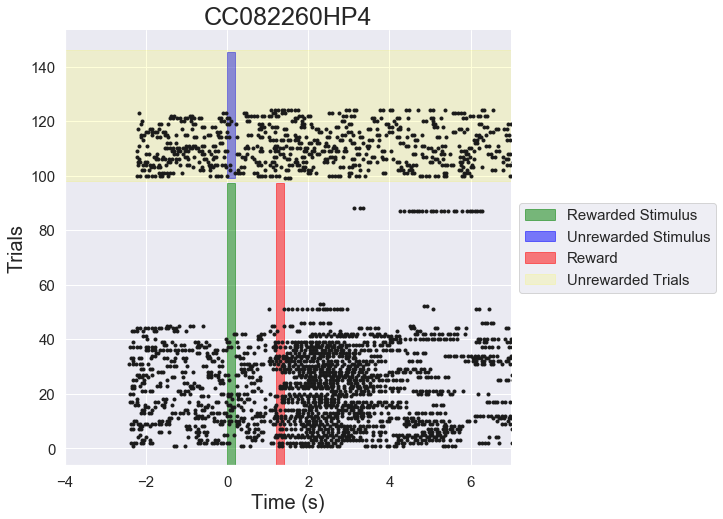

In [46]:
cc = path.split('/')[-1].split('_')[0]
hp = path.split('/')[-1].split('_')[1]
combo = cc+hp
# Plot licks across trials in the form of a raster plot
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8.0 # x dimension
fig_size[1] = 8.0 # y dimension


plt.plot( df_licks2.lick_time.values, df_licks2.trial, 'k.', label='_nolegend_')
sns.despine()

plt.xlim(-4, 7)
greenbar=plt.axvspan(stim_lb,stim_ub,0,0.65, color='green', alpha=0.5, label="Rewarded Stimulus")
bluebar=plt.axvspan(stim_lb,stim_ub,0.66,0.95, color='blue',alpha=0.5, label="Unrewarded Stimulus")
redbar=plt.axvspan(rew_lb, rew_ub,0,0.65, color='red',alpha=0.5, label="Reward") 
yellowbar=plt.axhspan(98,146, color='yellow',alpha=0.15, label="Unrewarded Trials")


plt.title(combo,fontsize=25)
plt.xlabel('Time (s)',fontsize=20)
plt.ylabel('Trials',fontsize=20)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(loc='center left', bbox_to_anchor=(1,0.5), prop={'size': 15})




# Cumulative Distribution

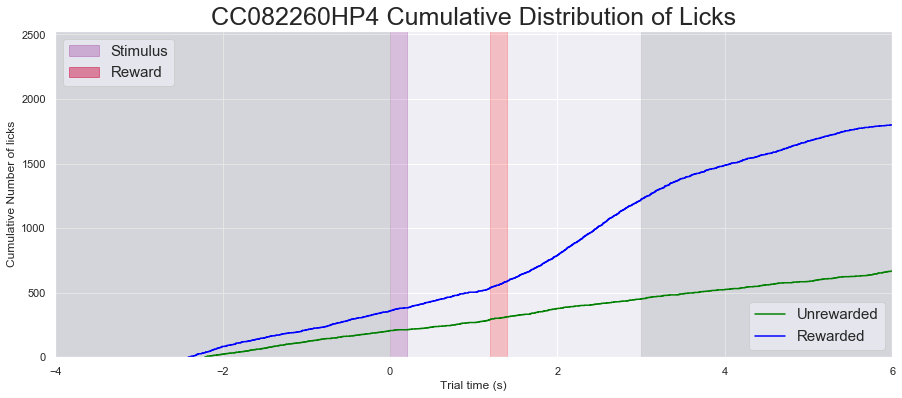

In [48]:
sns.set(rc={'figure.figsize':(15,6)})

sumc = sns.ecdfplot(data=df_licks2, x="lick_time", hue="stim id", stat="count", palette=['blue','green'],label = ("Rewarded", "Unrewarded"))
sumc.set(xlabel="Trial time (s)", ylabel="Cumulative Number of licks")


p1=plt.axvspan(stim_lb,stim_ub, color='purple', alpha=0.25, label = 'Stimulus')
p2=plt.axvspan(rew_lb, rew_ub, color='red', alpha=0.25, label = 'Reward') 
l1=plt.legend([ "Unrewarded", "Rewarded"], loc=4, prop={'size': 15})
#plt.legend(loc='center left', bbox_to_anchor=(1,0.5), prop={'size': 15})
l2=plt.legend([p1,(p1,p2)], ["Stimulus", "Reward"], loc = 2, prop={'size': 15})
plt.gca().add_artist(l1)

plt.xlim(-4, 6)
plt.title(combo+" Cumulative Distribution of Licks", fontsize=25)

plt.axvspan(-4,0, color='gray', alpha=0.2)
plt.axvspan(0,3, color = 'white', alpha=0.2)
plt.axvspan(3,6, color='gray', alpha=0.2)
        

plt.show()